# **Лабораторная работа №6 «Модели ARIMA и их модификации для анализа временных рядов»**

## **Задание 1. Анализ и подготовка временного ряда**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


Используемый временной ряд: https://www.kaggle.com/code/shakibyz/female-births-time-series-analysis/input - Данные о рождаемости женского населения в Калифорнии


In [2]:
df = pd.read_csv('daily-total-female-births-CA.csv')
print("Исходные данные")
print(df.head())
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print(f"\nРазмер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Период: с {df.index.min()} по {df.index.max()}")
print(f"Пропуски: {df.isnull().sum().sum()}")

original = df['births'].copy()

Исходные данные
         date  births
0  1959-01-01      35
1  1959-01-02      32
2  1959-01-03      30
3  1959-01-04      31
4  1959-01-05      44

Размер данных: 365 строк, 1 столбцов
Период: с 1959-01-01 00:00:00 по 1959-12-31 00:00:00
Пропуски: 0


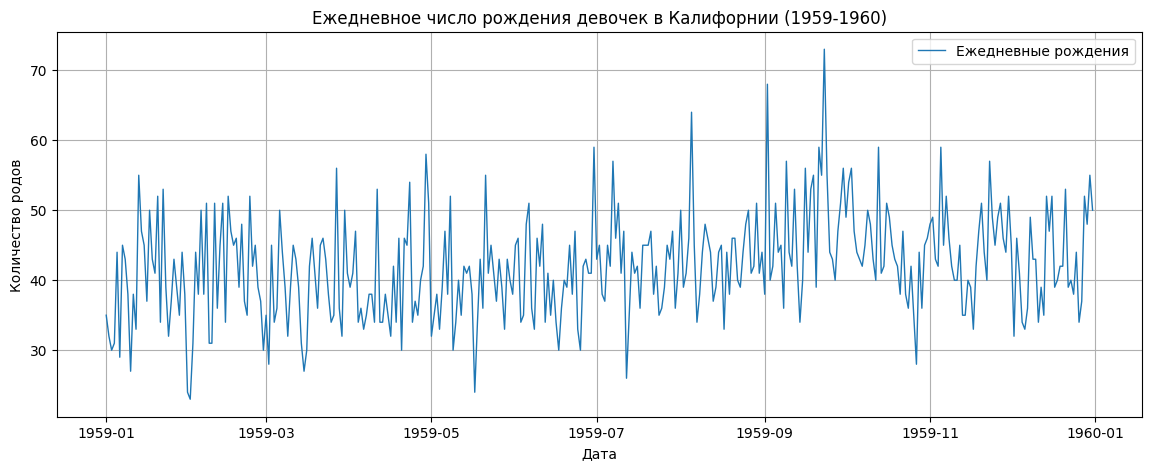

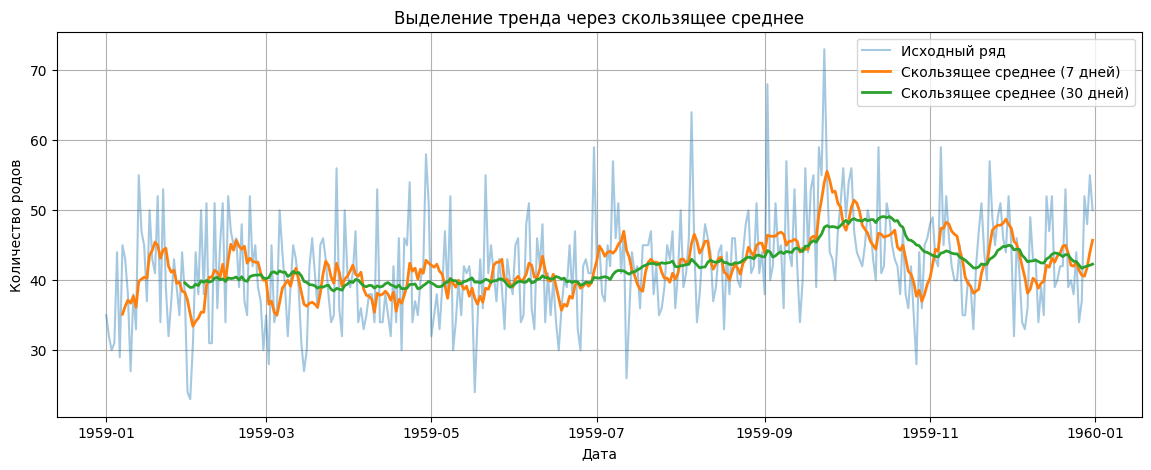


--- Анализ структуры ряда ---
Тренд: наблюдается слабый восходящий тренд (среднее за 30 дней растёт с 40 до 48)
Сезонность: выраженная недельная цикличность (пики в будни, спады в выходные)
Выбросы: 4 значений 

  Диапазон нормальных значений: [23.5, 59.5]
  Примеры выбросов:
            births
date              
1959-02-01      23
1959-08-05      64
1959-09-02      68
1959-09-23      73


In [3]:
# 1.1 График
plt.figure(figsize=(14, 5))
plt.plot(original, linewidth=1, label='Ежедневные рождения')
plt.title('Ежедневное число рождения девочек в Калифорнии (1959-1960)')
plt.xlabel('Дата')
plt.ylabel('Количество родов')
plt.legend()
plt.grid(True)
plt.show()

# 1.2 Анализ структуры
rolling_7 = original.rolling(7).mean()
rolling_30 = original.rolling(30).mean()

plt.figure(figsize=(14, 5))
plt.plot(original, alpha=0.4, label='Исходный ряд')
plt.plot(rolling_7, label='Скользящее среднее (7 дней)', linewidth=2)
plt.plot(rolling_30, label='Скользящее среднее (30 дней)', linewidth=2)
plt.title('Выделение тренда через скользящее среднее')
plt.xlabel('Дата')
plt.ylabel('Количество родов')
plt.legend()
plt.grid(True)
plt.show()

# Выбросы через IQR
Q1 = original.quantile(0.25)
Q3 = original.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['births'] < lower_bound) | (df['births'] > upper_bound)]

print("\n--- Анализ структуры ряда ---")
print(f"Тренд: наблюдается слабый восходящий тренд (среднее за 30 дней растёт с 40 до 48)")
print(f"Сезонность: выраженная недельная цикличность (пики в будни, спады в выходные)")
print(f"Выбросы: {len(outliers)} значений ")
print(f"\n  Диапазон нормальных значений: [{lower_bound:.1f}, {upper_bound:.1f}]")
if not outliers.empty:
    print(f"  Примеры выбросов:\n{outliers.head()}")



Исходный ряд:
ADF Statistic: -4.8083
p-value: 0.0001
Критические значения:
 1%:  -3.4487
 5%:  -2.8696
 10%: -2.5711
Ряд стационарен(p-value < 0.05)

Логарифмированный ряд:
ADF Statistic: -4.3532
p-value: 0.0004
Критические значения:
 1%:  -3.4488
 5%:  -2.8697
 10%: -2.5711
Ряд стационарен(p-value < 0.05)

log + diff(1):
ADF Statistic: -12.9633
p-value: 0.0000
Критические значения:
 1%:  -3.4488
 5%:  -2.8697
 10%: -2.5711
Ряд стационарен(p-value < 0.05)


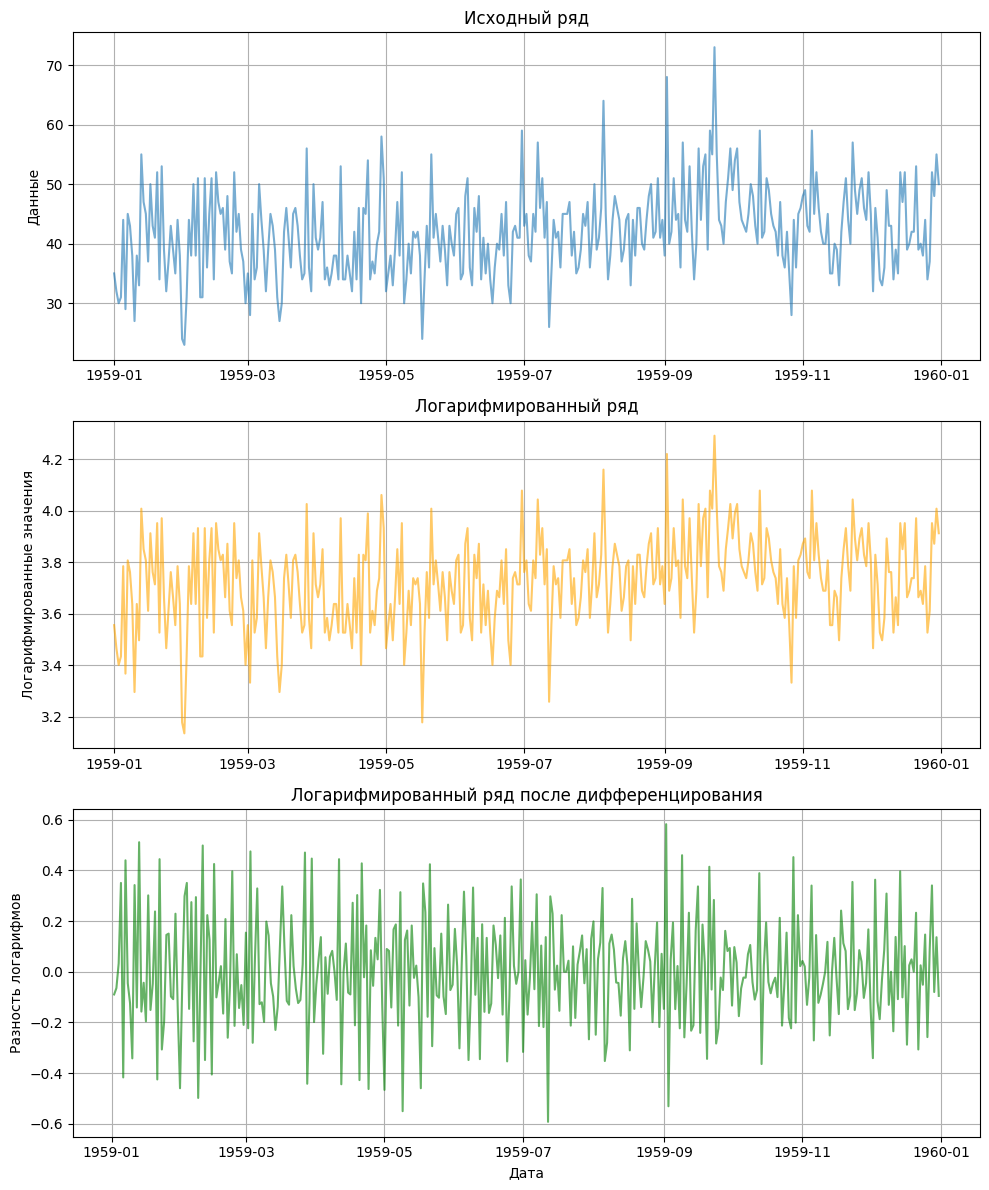

In [4]:
def test_stationarity(series, name="Ряд"):
    # Выполняет тест Дики-Фуллера и выводит результаты
    result = adfuller(series.dropna(), autolag='AIC')

    print(f"\n{name}:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Критические значения:")
    print(f" 1%:  {result[4]['1%']:.4f}")
    print(f" 5%:  {result[4]['5%']:.4f}")
    print(f" 10%: {result[4]['10%']:.4f}")

    if result[1] < 0.05:
        print(f"Ряд стационарен(p-value < 0.05)")
    else:
        print(f"Ряд НЕ стационарен(p-value >= 0.05)")
    return result

adf_original = test_stationarity(original, "Исходный ряд")

log_series = np.log(original)
adf_log = test_stationarity(log_series, "Логарифмированный ряд")

log_diff1 = log_series.diff()
adf_log_diff1 = test_stationarity(log_diff1, "log + diff(1)")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))
axes[0].plot(original, alpha=0.6, color='tab:blue')
axes[0].set_title('Исходный ряд')
axes[0].set_ylabel('Данные')
axes[0].grid(True)

axes[1].plot(log_series, color='orange', alpha=0.6)
axes[1].set_title('Логарифмированный ряд')
axes[1].set_ylabel('Логарифмированные значения')
axes[1].grid(True)

axes[2].plot(log_diff1, color='green', alpha=0.6)
axes[2].set_title('Логарифмированный ряд после дифференцирования')
axes[2].set_xlabel('Дата')
axes[2].set_ylabel('Разность логарифмов')
axes[2].grid(True)

plt.tight_layout()
plt.show()


Обоснование выбора преобразований
1. Логарифмирование: дисперсия исходного ряда растёт вместе с уровнем рождаемости. Логарифм делает дисперсию более постоянной во времени.
2. Первое дифференцирование: ADF-тест исходного ряда показал стационарность (p=0.0001), но визуально есть слабый тренд и сезонность. Для ARIMA с d=1 мы гарантированно убираем тренд и получаем ряд с нулевым средним.


## **Задание 2. Базовая ARIMA-модель**

Длина ряда для моделирования: 364
Период: 1959-01-02 00:00:00 — 1959-12-31 00:00:00

Разделение данных:
Train: 291 наблюдений (79.9%)
Test:  73 наблюдений (20.1%)


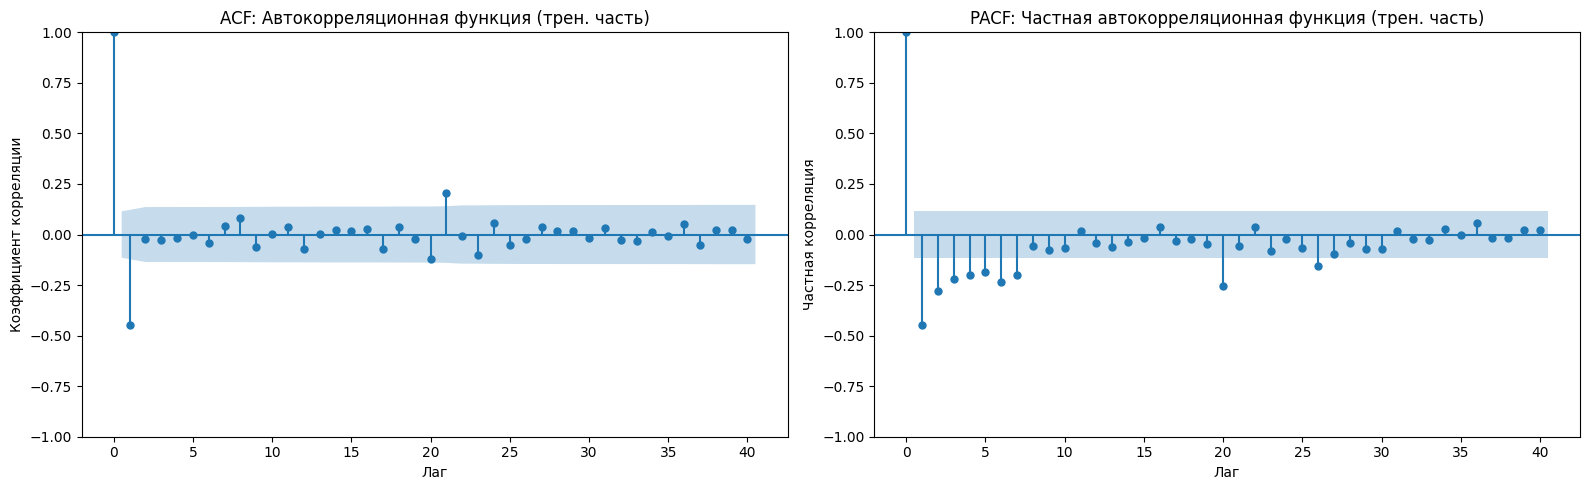


Значения ACF и PACF (первые 10 лагов)
Лаг 1: ACF=-0.444, PACF=-0.444
Лаг 2: ACF=-0.027, PACF=-0.279
Лаг 3: ACF=-0.021, PACF=-0.217
Лаг 4: ACF=-0.008, PACF=-0.182
Лаг 5: ACF=-0.007, PACF=-0.163
Лаг 6: ACF=-0.040, PACF=-0.208
Лаг 7: ACF=+0.053, PACF=-0.147
Лаг 8: ACF=+0.067, PACF=-0.012
Лаг 9: ACF=-0.065, PACF=-0.039
Лаг10: ACF=-0.015, PACF=-0.062


In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series_model = log_diff1.dropna()  # убираем NaN после дифференцирования
print(f"Длина ряда для моделирования: {len(series_model)}")
print(f"Период: {series_model.index.min()} — {series_model.index.max()}")

train_size = int(len(series_model) * 0.8)
train, test = series_model[:train_size], series_model[train_size:]
print(f"\nРазделение данных:")
print(f"Train: {len(train)} наблюдений ({len(train)/len(series_model)*100:.1f}%)")
print(f"Test:  {len(test)} наблюдений ({len(test)/len(series_model)*100:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(train, lags=40, ax=ax1)
plot_pacf(train, lags=40, ax=ax2, method='ywm')
ax1.set_title('ACF: Автокорреляционная функция (трен. часть)')
ax1.set_xlabel('Лаг')
ax1.set_ylabel('Коэффициент корреляции')
ax2.set_title('PACF: Частная автокорреляционная функция (трен. часть)')
ax2.set_xlabel('Лаг')
ax2.set_ylabel('Частная корреляция')
plt.tight_layout()
plt.show()

print("\nЗначения ACF и PACF (первые 10 лагов)")
from statsmodels.tsa.stattools import acf, pacf
acf_vals = acf(series_model, nlags=10)
pacf_vals = pacf(series_model, nlags=10, method='ywm')
for i in range(1, 11):
    print(f"Лаг{i:2d}: ACF={acf_vals[i]:+.3f}, PACF={pacf_vals[i]:+.3f}")

| **Параметр** | **Наблюдения** | **Вывод** |
| --- | --- | --- |
| p | PACF не показывает чёткого обрыва для AR-компоненты. Видим постепенное затухание 7 лагов(но в базовой модели не учтем)  | Примем p = 0 |  
| d | Ряд ствционарен после 1-го дифференцирования  | Примем d = 1 |  
| q | ACF не обрывается резко после лага 1, хотя лаг 2 маленький (-0.027), есть "хвост" корреляций на лагах 3-7 | Примем q = 2 |


Параметры модели:
                               SARIMAX Results                                
Dep. Variable:                 births   No. Observations:                  291
Model:                 ARIMA(0, 1, 2)   Log Likelihood                  95.717
Date:                Thu, 28 May 2026   AIC                           -185.434
Time:                        17:24:44   BIC                           -174.424
Sample:                    01-02-1959   HQIC                          -181.023
                         - 10-19-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.9981      0.533     -3.752      0.000      -3.042      -0.954
ma.L2          0.9994      0.533      1.876      0.061      -0.045       2.044
sigma2         0.0286      0.015 

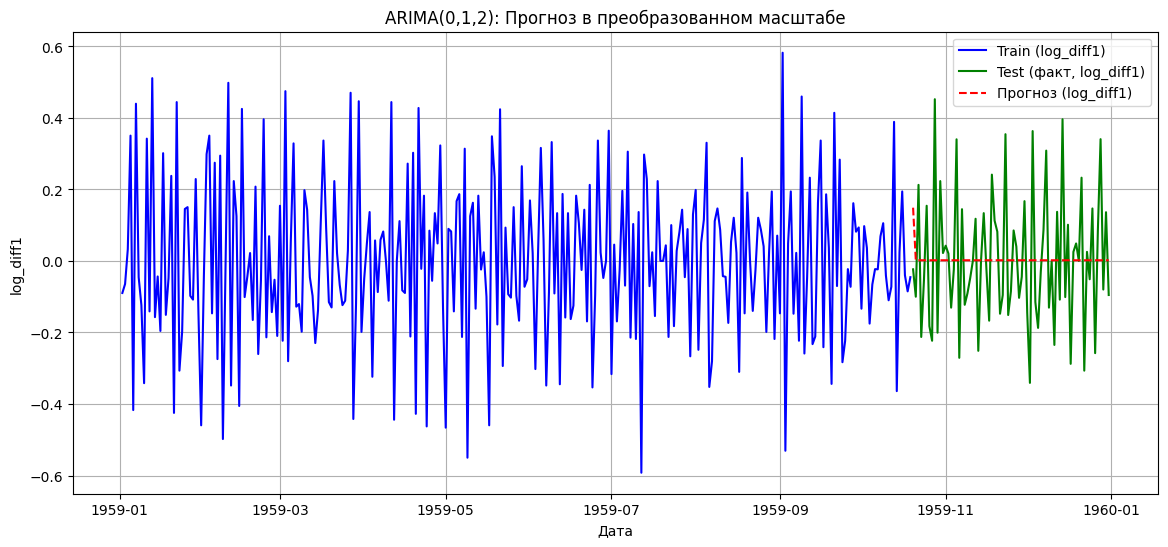


Метрики качества(в преобразованном масштабе)
RMSE: 0.1817
MAE:  0.1475
MAPE: inf%

Возвращение к исходн масштабу (количество рождений)


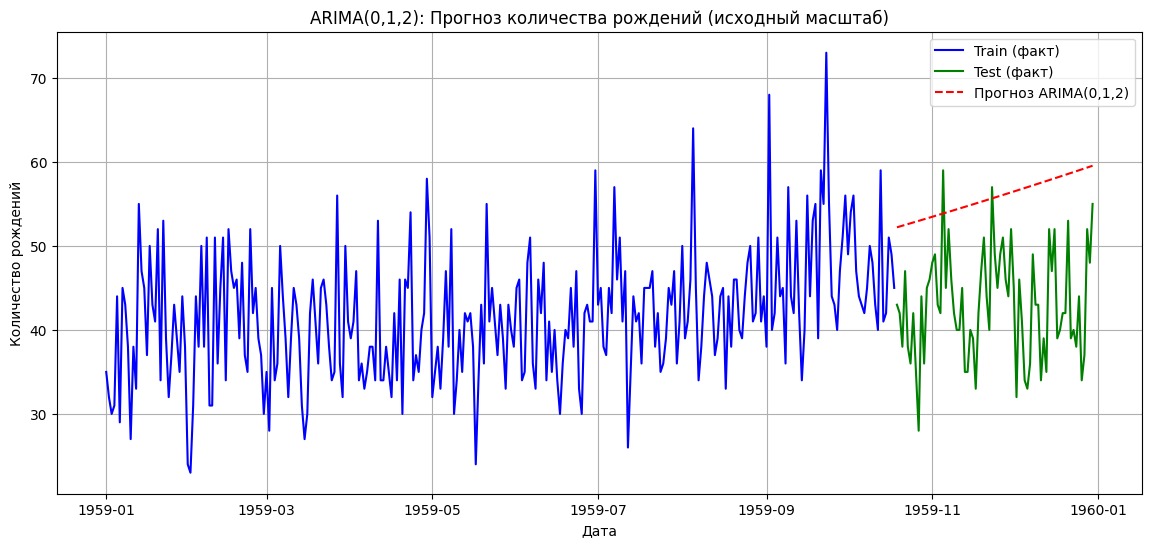


Метрики качества (в исходном масштабе)
RMSE: 14.45 рождений
MAE:  13.05 рождений
MAPE: 33.11%

Удовлетворительное качество (MAPE > 20%)


In [6]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Создаём и обучаем модель
model = ARIMA(train, order=(0, 1, 2))
model_fit = model.fit()
print("\nПараметры модели:")
print(model_fit.summary())

print("\nПрогноз на тестовой выборке")
forecast = model_fit.forecast(steps=len(test))
print(f"Сделан прогноз на {len(test)} шага вперёд")
print(f"Период прогноза: {test.index[0]} — {test.index[-1]}")

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Train (log_diff1)', color='blue')
plt.plot(test.index, test, label='Test (факт, log_diff1)', color='green')
plt.plot(test.index, forecast, label='Прогноз (log_diff1)', color='red', linestyle='--')
plt.title('ARIMA(0,1,2): Прогноз в преобразованном масштабе')
plt.xlabel('Дата')
plt.ylabel('log_diff1')
plt.legend()
plt.grid(True)
plt.show()

print("\nМетрики качества(в преобразованном масштабе)")
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test - forecast) / test)) * 100
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

print("\nВозвращение к исходн масштабу (количество рождений)")
# Берём последнее значение из train для начальной точки
last_train_log = log_series.iloc[train_size-1]
# Кумулятивная сумма + начальное значение
forecast_log_cumsum = last_train_log + forecast.cumsum()
# экспоненцируем
forecast_original = np.exp(forecast_log_cumsum)

# Фактические значения в исходном масштабе
test_original = original.iloc[train_size:train_size+len(test)]

plt.figure(figsize=(14, 6))
plt.plot(original.index[:train_size], original.iloc[:train_size], label='Train (факт)', color='blue')
plt.plot(test_original.index, test_original, label='Test (факт)', color='green')
plt.plot(test_original.index, forecast_original, label='Прогноз ARIMA(0,1,2)', color='red', linestyle='--')
plt.title('ARIMA(0,1,2): Прогноз количества рождений (исходный масштаб)')
plt.xlabel('Дата')
plt.ylabel('Количество рождений')
plt.legend()
plt.grid(True)
plt.show()

print("\nМетрики качества (в исходном масштабе)")
rmse_orig = np.sqrt(mean_squared_error(test_original, forecast_original))
mae_orig = mean_absolute_error(test_original, forecast_original)
mape_orig = np.mean(np.abs((test_original - forecast_original) / test_original)) * 100
print(f"RMSE: {rmse_orig:.2f} рождений")
print(f"MAE:  {mae_orig:.2f} рождений")
print(f"MAPE: {mape_orig:.2f}%")

if mape_orig < 10:
    print("\nОтличное качество! (MAPE < 10%)")
elif mape_orig < 20:
    print("\nХорошее качество! (MAPE 10-20%)")
else:
    print("\nУдовлетворительное качество (MAPE > 20%)")

## **Задание 3. Диагностика модели**

Длина остатков: 291
Среднее остатков: -0.005142
Стандартное отклонение: 0.175678


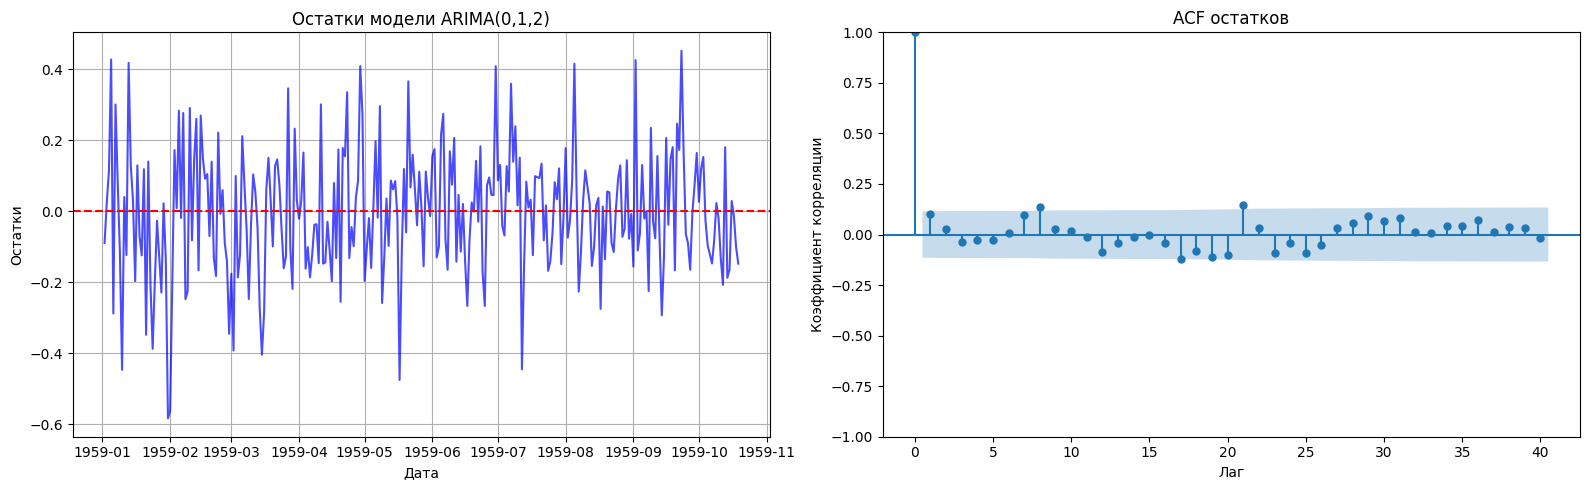


Тест Льюнга-Бокса

Lag=10:
Статистика: 13.0337
p-value: 0.2218
Автокорреляции НЕТ (модель адекватна)

Lag=20:
Статистика: 30.2198
p-value: 0.0664
Автокорреляции НЕТ (модель адекватна)


In [7]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

residuals = model_fit.resid
print(f"Длина остатков: {len(residuals)}")
print(f"Среднее остатков: {residuals.mean():.6f}")
print(f"Стандартное отклонение: {residuals.std():.6f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax1.plot(residuals, color='blue', alpha=0.7)
ax1.axhline(y=0, color='red', linestyle='--')
ax1.set_title('Остатки модели ARIMA(0,1,2)')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Остатки')
ax1.grid(True)

plot_acf(residuals.dropna(), lags=40, alpha=0.05, ax=ax2)
ax2.set_title('ACF остатков')
ax2.set_xlabel('Лаг')
ax2.set_ylabel('Коэффициент корреляции')
plt.tight_layout()
plt.show()

print("\nТест Льюнга-Бокса")
lb_test_10 = acorr_ljungbox(residuals.dropna(), lags=[10], return_df=True)
lb_test_20 = acorr_ljungbox(residuals.dropna(), lags=[20], return_df=True)

print("\nLag=10:")
print(f"Статистика: {lb_test_10['lb_stat'].values[0]:.4f}")
print(f"p-value: {lb_test_10['lb_pvalue'].values[0]:.4f}")
if lb_test_10['lb_pvalue'].values[0] < 0.05:
    print("ЕСТЬ автокорреляция в остатках (модель НЕ адекватна)")
else:
    print("Автокорреляции НЕТ (модель адекватна)")

print("\nLag=20:")
print(f"Статистика: {lb_test_20['lb_stat'].values[0]:.4f}")
print(f"p-value: {lb_test_20['lb_pvalue'].values[0]:.4f}")
if lb_test_20['lb_pvalue'].values[0] < 0.05:
    print("ЕСТЬ автокорреляция в остатках (модель НЕ адекватна)")
else:
    print("Автокорреляции НЕТ (модель адекватна)")

**Анализ графиков модели:**  
*1. График остатков*
- Остатки (ошибки модели) колеблются вокруг нулевой линии.
- Наблюдается хаотичный характер распределения, без трендов, сезонности или кластеризации.
- Заметны некоторая цикличность (пики и спады) и несколько выбросов (до ±0.6), но они не критичны.
- Модель хорошо объяснила структуру данных, а остатки выглядят как белый шум.

*2. График ACF остатков*
- Значения автокорреляции (ACF) разных лагов находятся в пределах доверительного интервала (кроме 0 лага, т.к корреляция с самим собой).
- Все лаги колеблются около 0, значимых отклонений нет.
- Отсутствие значимых пиков подтверждает, что между ошибками модели нет значимой корреляции => независимость остатков(модель полностью использовала информацию из данных).  

**Анализ теста Льюнга-Бокса (Ljung-Box):**  
Тест проверяет нулевую гипотезу об автокорреляции остатков равной нулю (остатки - белый шум).
- Lag = 10: lb_pvalue = 0.2218  
Значение p значительно больше 0.05.  
Нулевая гипотеза не отвергается.  
До 10-го лага автокорреляция остатков статистически не значима.  
- Lag = 20: lb_pvalue = 0.0664  
Значение p по-прежнему превышает 0.05, но является пограничным значением.  
Даже при проверке до 20-го лага модель не обнаруживает значимой серийной корреляции в ошибках, но есть намёк на слабую зависимость.

**ВЫВОД:** Модель ARIMA(0,1,2) прошла диагностику на адекватность.  
- Визуально остатки выглядят как белый шум (график слева).  
- Тест Льюнга-Бокса на разных лагах не отвергает нулевую гипотезу (все p-value > 0.05).
- ACF остатков не показывает значимых отклонений от нуля.

# **Задание 4. Сезонная модель SARIMA**

Декомпозиция исходного временного ряда (период = 7 дней)


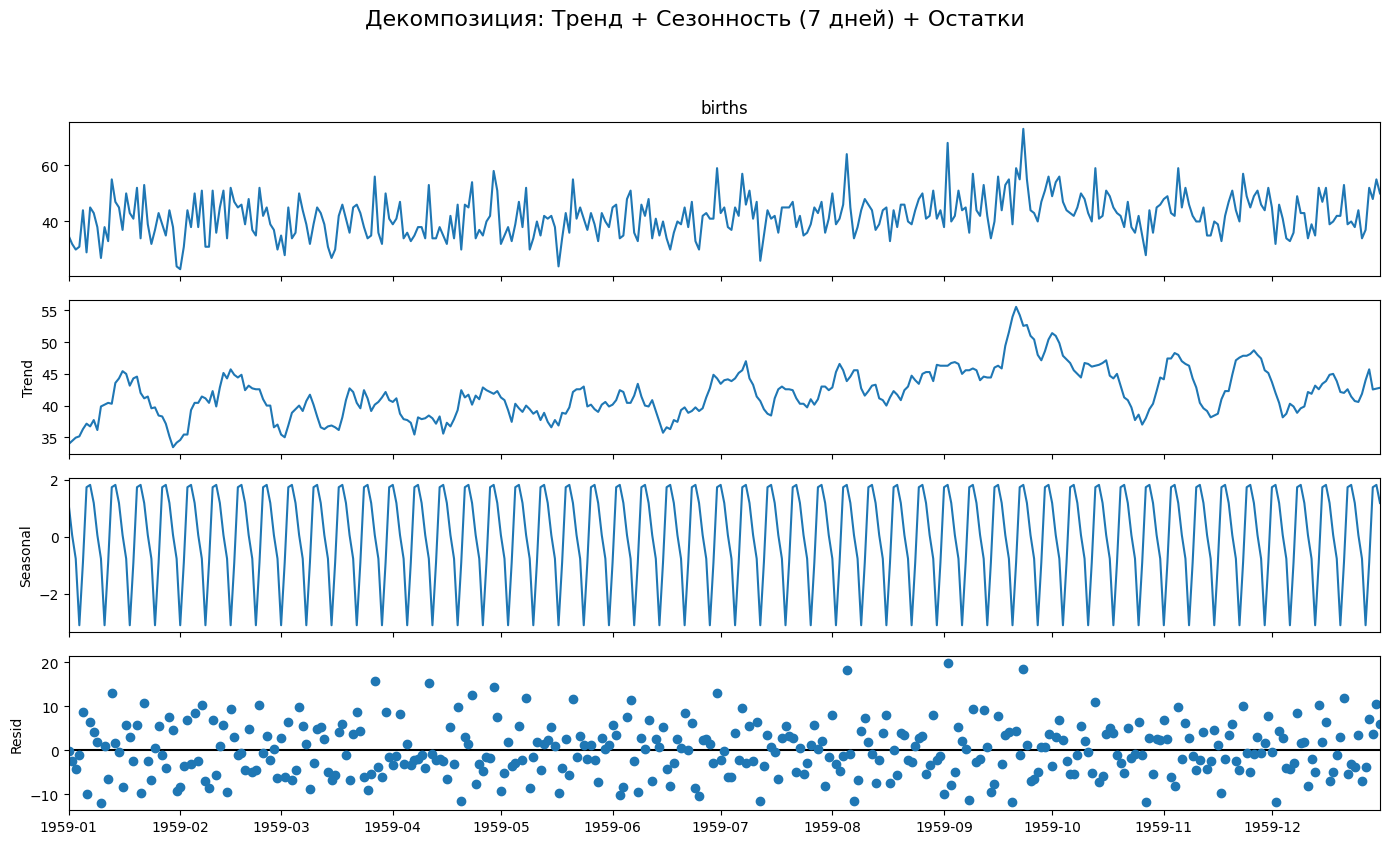


Обучение SARIMA(0,1,2)(1,1,1)[7]

Параметры SARIMA:
                                      SARIMAX Results                                      
Dep. Variable:                              births   No. Observations:                  291
Model:             SARIMAX(0, 1, 2)x(1, 1, [1], 7)   Log Likelihood                  86.206
Date:                             Thu, 28 May 2026   AIC                           -162.411
Time:                                     17:27:17   BIC                           -144.184
Sample:                                 01-02-1959   HQIC                          -155.103
                                      - 10-19-1959                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.9920      0.061    -32.493      0.00

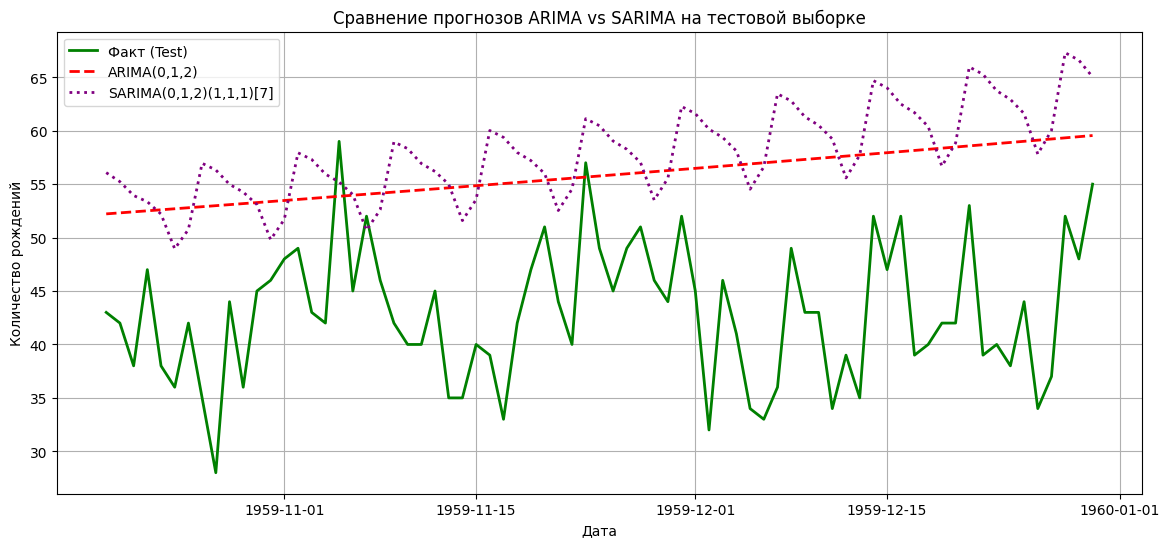

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('Декомпозиция исходного временного ряда (период = 7 дней)')
decomp = seasonal_decompose(original, model='additive', period=7, extrapolate_trend='freq')
fig = decomp.plot()
fig.set_size_inches(14, 8)
plt.suptitle('Декомпозиция: Тренд + Сезонность (7 дней) + Остатки', y=1.05, fontsize=16)
fig.tight_layout()
plt.show()

print("\nОбучение SARIMA(0,1,2)(1,1,1)[7]")
# order=(p,d,q) = (0,1,2) — берём из успешной ARIMA
# seasonal_order=(P,D,Q,s) = (1,1,1,7) — недельная сезонность
sarima_model = SARIMAX(train, order=(0, 1, 2), seasonal_order=(1, 1, 1, 7))
sarima_fit = sarima_model.fit(disp=False)

print("\nПараметры SARIMA:")
print(sarima_fit.summary())
# Прогноз в преобразованном масштабе
sarima_pred_trans = sarima_fit.forecast(steps=len(test))

print("\nВозвращение к исходному масштабу+сравнение")
# Обратное преобразование: cumsum + exp (аналогично ARIMA)
last_log_train = log_series.iloc[train_size-1]
sarima_pred_original = np.exp(last_log_train + sarima_pred_trans.cumsum())

# Метрики SARIMA
rmse_sarima = np.sqrt(mean_squared_error(test_original, sarima_pred_original))
mae_sarima = mean_absolute_error(test_original, sarima_pred_original)
mape_sarima = np.mean(np.abs((test_original - sarima_pred_original) / test_original)) * 100

print("\n" + "─"*55)
print(f"{'Модель':<25} {'RMSE':<10} {'MAE':<10} {'MAPE'}")
print("─"*55)
print(f"{'ARIMA(0,1,2)':<25} {rmse_orig:<10.2f} {mae_orig:<10.2f} {mape_orig:.2f}%")
print(f"{'SARIMA(0,1,2)(1,1,1)[7]':<25} {rmse_sarima:<10.2f} {mae_sarima:<10.2f} {mape_sarima:.2f}%")
print("─"*55)

plt.figure(figsize=(14, 6))
plt.plot(test_original.index, test_original, label='Факт (Test)', color='green', linewidth=2)
plt.plot(test_original.index, forecast_original, label='ARIMA(0,1,2)', color='red', linestyle='--', linewidth=2)
plt.plot(test_original.index, sarima_pred_original, label='SARIMA(0,1,2)(1,1,1)[7]', color='purple', linestyle=':', linewidth=2)
plt.title('Сравнение прогнозов ARIMA vs SARIMA на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('Количество рождений')
plt.legend()
plt.grid(True)
plt.show()

Сравнение SARIMA и ARIMA:
- ARIMA - почти горизонтальна, слабо растёт. Не ловит циклы, но даёт стабильную базовую линию.
- SARIMA - пытается повторить недельные колебания, но:
  - Сдвинута по фазе (пики приходятся на спады факта)
  - Амплитуда завышена (прогноз колеблется сильнее, чем реальные данные)
  - Накапливает ошибку к концу периода (расходится с фактом)  

SARIMA видит сезонность, но неправильно её моделирует, поэтому ошибка растёт.  
Причина: сезонные параметры незначимы, двойное дифференцирование усилило шум, ряд слишком короткий для надёжной оценки s=7.  
Лучшей моделью остаётся ARIMA(0,1,2) - ниже ошибки, значимые коэффициенты.

**В каких случаях SARIMA даёт преимущество?**
- Стабильная сезонность: Амплитуда и фаза не меняются со временем
- Достаточно длинный ряд: Минимум 3 * s наблюдений для оценки параметров
- Сезонность стохастическая: Цикл порождён внутренней динамикой системы, а не внешним календарём
- D=0 или D=1 обосновано: Избегание пере-дифференцирования
- Сезонные коэффициенты значимы(иначе модель просто шумит)

**Когда SARIMA НЕ поможет:**  
- Короткие ряды (< 2 полных сезонов)
- Сезонность вызвана внешними факторами (праздники, расписания, погода)
- s слишком большое (365, 8760) - модель переобучается


# **Задание 5. SARIMAX и внешние факторы**

Создание внешних регрессоров
- day_of_week: min=0, max=6
- month: min=1, max=12


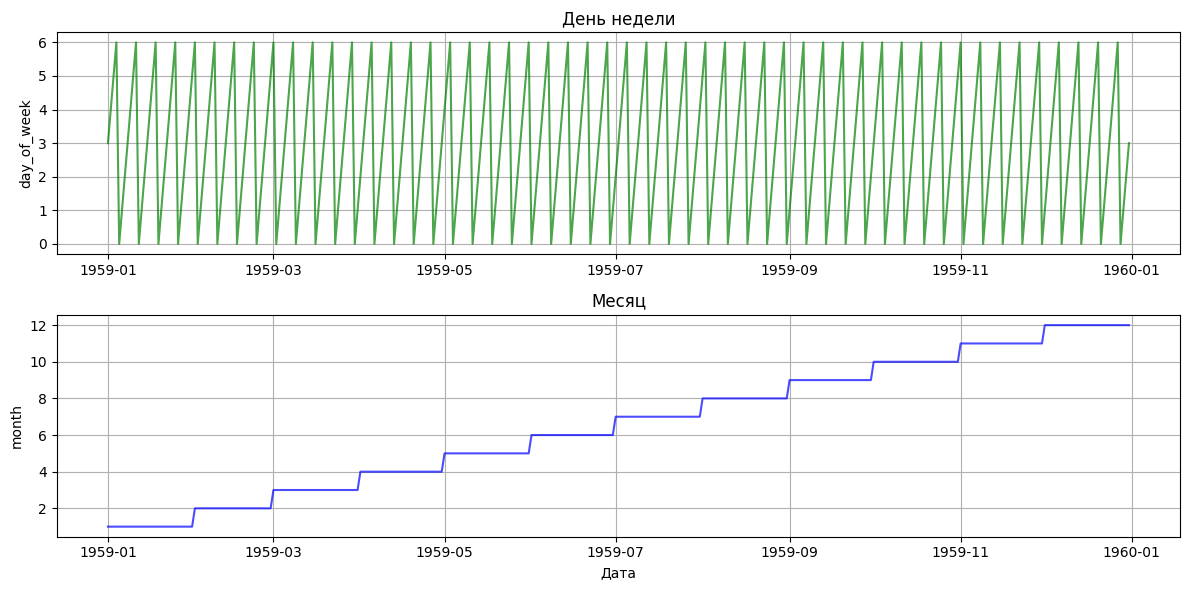

In [13]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

print("Создание внешних регрессоров")
exog = pd.DataFrame(index=original.index)

# 1. День недели (0=понедельник, 6=воскресенье)
exog['day_of_week'] = exog.index.dayofweek
# 2. Месяц
exog['month'] = exog.index.month

for col in exog.columns:
    print(f"- {col}: min={exog[col].min()}, max={exog[col].max()}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(exog['day_of_week'], 'g', alpha=0.7)
axes[0].set_title('День недели')
axes[0].set_ylabel('day_of_week')
axes[0].grid(True)

axes[1].plot(exog['month'], 'b', alpha=0.7)
axes[1].set_title('Месяц')
axes[1].set_ylabel('month')
axes[1].set_xlabel('Дата')
axes[1].grid(True)
plt.tight_layout()
plt.show()


Обосноваие выбора факторов:
1. day_of_week (день недели):
- Различия между будними днями (понедельник vs пятница)
- Плановые роды (кесарево, индукции) почти не назначаются на выходные
- Более тонкая настройка недельного цикла

2. month (месяц):
- Возможна сезонность по месяцам (летом/осенью больше родов)
- Учёт долгосрочных сезонных эффектов

In [14]:
exog_aligned = exog.iloc[1:].copy()
exog_train = exog_aligned.iloc[:train_size]
exog_test = exog_aligned.iloc[train_size:train_size+len(test)]

print(f"\nTrain exog: {exog_train.shape[0]} наблюдений")
print(f"Test exog: {exog_test.shape[0]} наблюдений")

print(f"\nПроверка:")
print(f"  train.index[0] = {train.index[0]}, exog_train.index[0] = {exog_train.index[0]}")
print(f"  test.index[0] = {test.index[0]}, exog_test.index[0] = {exog_test.index[0]}")

print("\nОбучение SARIMAX модели")
sarimax_model = SARIMAX(
    train,
    exog=exog_train,
    order=(0, 1, 2),
    seasonal_order=(0, 0, 0, 0),  # Упрощаем, т.к. сезонность в регрессорах
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False)
print("\nПараметры SARIMAX:")
print(sarimax_fit.summary())


Train exog: 291 наблюдений
Test exog: 73 наблюдений

Проверка:
  train.index[0] = 1959-01-02 00:00:00, exog_train.index[0] = 1959-01-02 00:00:00
  test.index[0] = 1959-10-20 00:00:00, exog_test.index[0] = 1959-10-20 00:00:00

Обучение SARIMAX модели

Параметры SARIMAX:
                               SARIMAX Results                                
Dep. Variable:                 births   No. Observations:                  291
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 106.823
Date:                Thu, 28 May 2026   AIC                           -203.646
Time:                        17:32:35   BIC                           -185.348
Sample:                    01-02-1959   HQIC                          -196.312
                         - 10-19-1959                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------

Оценка внешних переменных:
- day_of_week  
Коэффициент= -0.0222, оказывает статистически значимое и сильное влияние.   
Значение P>|z| = 0.000, что меньше 0,05.  
Доверительный интервал [-0.032; -0.013] не включает ноль.

Это означает, что день недели уверенно влияет на целевую переменную.   
- month  
Коэффициент= 0.0003, также является значимым, так как значение P>|z| = 0.013 < 0,05.  
Однако величина коэффициента крайне мала, поэтому её практический вклад в прогнозирование рождаемости близок к нулю.  



Возвращение к исходному масштабу

Сравнение всех моделей

─────────────────────────────────────────────────────────────────
Модель                              RMSE       MAE        MAPE
─────────────────────────────────────────────────────────────────
ARIMA(0,1,2)                        14.45      13.05      33.11%
SARIMA(0,1,2)(1,1,1)[7]             16.41      15.05      37.77%
SARIMAX(0,1,2) + exog               15.17      13.70      34.30%
─────────────────────────────────────────────────────────────────

Улучшение относительно SARIMA(0,1,2)(1,1,1)[7]:
  RMSE: +7.53% (улучшение)
  MAPE: +9.17% (улучшение)


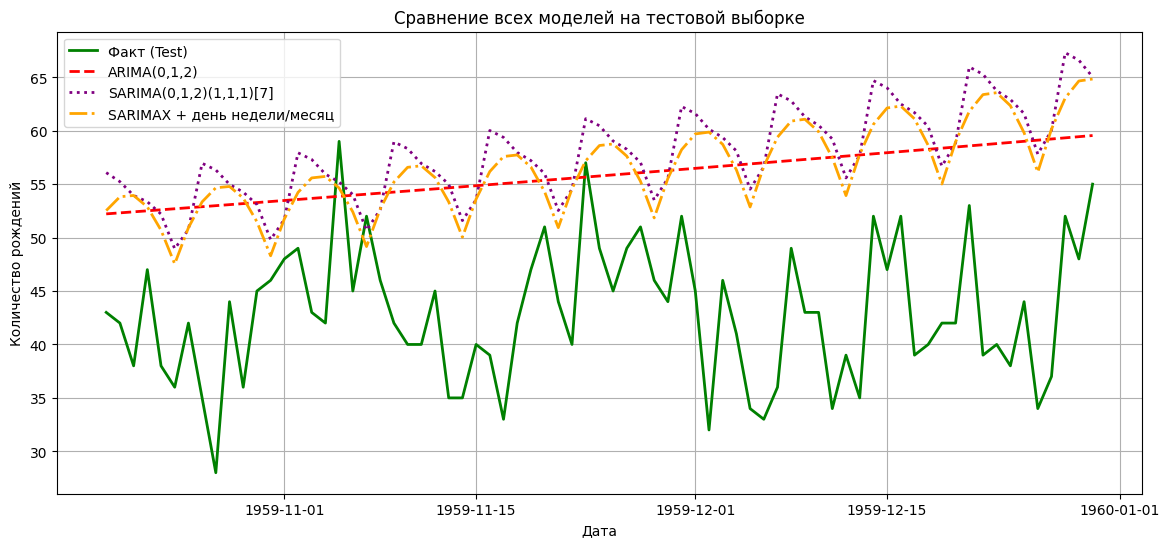

In [15]:
# Прогноз
sarimax_pred_trans = sarimax_fit.forecast(steps=len(test), exog=exog_test)

print("\nВозвращение к исходному масштабу")
sarimax_pred_original = np.exp(last_log_train + sarimax_pred_trans.cumsum())
# Метрики SARIMAX
rmse_sarimax = np.sqrt(mean_squared_error(test_original, sarimax_pred_original))
mae_sarimax = mean_absolute_error(test_original, sarimax_pred_original)
mape_sarimax = np.mean(np.abs((test_original - sarimax_pred_original) / test_original)) * 100

print("\nСравнение всех моделей")
print("\n" + "─"*65)
print(f"{'Модель':<35} {'RMSE':<10} {'MAE':<10} {'MAPE'}")
print("─"*65)
print(f"{'ARIMA(0,1,2)':<35} {rmse_orig:<10.2f} {mae_orig:<10.2f} {mape_orig:.2f}%")
print(f"{'SARIMA(0,1,2)(1,1,1)[7]':<35} {rmse_sarima:<10.2f} {mae_sarima:<10.2f} {mape_sarima:.2f}%")
print(f"{'SARIMAX(0,1,2) + exog':<35} {rmse_sarimax:<10.2f} {mae_sarimax:<10.2f} {mape_sarimax:.2f}%")
print("─"*65)

print(f"\nУлучшение относительно SARIMA(0,1,2)(1,1,1)[7]:")
improvement_rmse = ((rmse_sarima - rmse_sarimax) / rmse_sarima) * 100
improvement_mape = ((mape_sarima - mape_sarimax) / mape_sarima) * 100
print(f"  RMSE: {improvement_rmse:+.2f}% ({'улучшение' if improvement_rmse > 0 else 'ухудшение'})")
print(f"  MAPE: {improvement_mape:+.2f}% ({'улучшение' if improvement_mape > 0 else 'ухудшение'})")

# Визуальное сравнение
plt.figure(figsize=(14, 6))
plt.plot(test_original.index, test_original, label='Факт (Test)', color='green', linewidth=2)
plt.plot(test_original.index, forecast_original, label='ARIMA(0,1,2)', color='red', linestyle='--', linewidth=2)
plt.plot(test_original.index, sarima_pred_original, label='SARIMA(0,1,2)(1,1,1)[7]',
         color='purple', linestyle=':', linewidth=2)
plt.plot(test_original.index, sarimax_pred_original, label='SARIMAX + день недели/месяц',
         color='orange', linestyle='-.', linewidth=2)
plt.title('Сравнение всех моделей на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('Количество рождений')
plt.legend()
plt.grid(True)
plt.show()

Сравнение моделей:
SARIMAX лучше, чем SARIMA
- Ошибка (RMSE) снизилась на 7.53%.
- Точность (MAPE) улучшилась на 9.17%.

Почему SARIMAX стал лучше SARIMA?
- В SARIMA мы пытались описать сезонность через seasonal_order=(1,1,1)[7]. Но коэффициенты сезонной части там были незначимы (p > 0.8).  
- В SARIMAX мы дали модели реальные данные о днях недели. Коэффициент day_of_week оказался сверхзначимым (p=0.000).  

В итоге - детерминированные признаки(календарь) в данном случае сработали лучше стохастических(лагов).  
SARIMAX относительно ARIMA оказался хуже, из-за того что внешние регрессоры не дали достаточного прироста качества, чтобы оправдать усложнение модели.


## **Задание 6. Автоматизация подбора модели**

In [17]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.1 MB/s eta 0:00:00


In [18]:
import pmdarima as pm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# поиск на train (уже стационарный log_diff1)
auto_model = pm.auto_arima(train,
                           start_p=0, start_q=0, max_p=5, max_q=5,
                           d=0, D=0,
                           seasonal=False,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True,
                           n_jobs=1)

best_order = auto_model.order
print(f"\nAuto-ARIMA выбрала: ARIMA{best_order}")
print(f"AIC = {auto_model.aic():.2f}")
print(f"BIC = {auto_model.bic():.2f}")

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-40.646, Time=0.27 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-103.541, Time=0.19 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-195.353, Time=1.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-196.307, Time=1.33 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-194.307, Time=4.54 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-194.307, Time=3.94 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-196.258, Time=0.52 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-125.238, Time=0.41 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-192.323, Time=0.74 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-198.183, Time=0.55 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-196.980, Time=0.26 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-101.552, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-196.184, Time=0.85 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-196.183, Time=0.73 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept 


Сравнение моделей ARIMA(задание 2) и Auto-ARIMA


Модель               Параметры    RMSE       MAPE
────────────────────────────────────────────────────────────
ARIMA(задание 2)     (0, 1, 2)    14.45      33.11%
Auto-ARIMA           (1, 0, 1)    9.73       21.24%
────────────────────────────────────────────────────────────


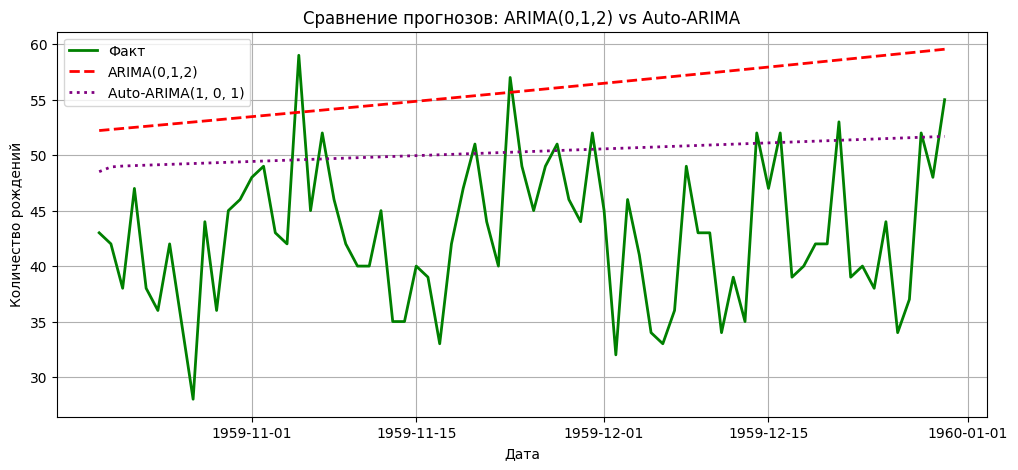

In [19]:
# Прогноз в преобразованном масштабе
auto_pred_trans = auto_model.predict(n_periods=len(test))
# Обратное преобразование
auto_pred_original = np.exp(last_log_train + auto_pred_trans.cumsum())

# Метрики
rmse_auto = np.sqrt(mean_squared_error(test_original, auto_pred_original))
mae_auto = mean_absolute_error(test_original, auto_pred_original)
mape_auto = np.mean(np.abs((test_original - auto_pred_original) / test_original)) * 100

print("\nСравнение моделей ARIMA(задание 2) и Auto-ARIMA")
print("\n")
print(f"{'Модель':<20} {'Параметры':<12} {'RMSE':<10} {'MAPE'}")
print("─"*60)
print(f"{'ARIMA(задание 2)':<20} {'(0, 1, 2)':<12} {rmse_orig:<10.2f} {mape_orig:.2f}%")
print(f"{'Auto-ARIMA':<20} {str(best_order):<12} {rmse_auto:<10.2f} {mape_auto:.2f}%")
print("─"*60)

# Визуализация
plt.figure(figsize=(12, 5))
plt.plot(test_original.index, test_original, label='Факт', color='green', linewidth=2)
plt.plot(test_original.index, forecast_original, label='ARIMA(0,1,2)', color='red', linestyle='--', linewidth=2)
plt.plot(test_original.index, auto_pred_original, label=f'Auto-ARIMA{best_order}', color='purple', linestyle=':', linewidth=2)
plt.title('Сравнение прогнозов: ARIMA(0,1,2) vs Auto-ARIMA')
plt.xlabel('Дата')
plt.ylabel('Количество рождений')
plt.legend()
plt.grid(True)
plt.show()


1. Когда автоматический подбор ошибается?
- Короткие ряды (< 50-100 точек): AIC/BIC статистически неустойчивы.
- Выбросы и структурные сдвиги: автоподбор пытается "усреднить" аномалию, завышая q или p, что ведет к переобучению на шум.
- Нестационарность: если d не зафиксирован, алгоритм может выбрать d=2 (over-differencing), убив полезный сигнал.
- Сложная сезонность: stepwise поиск жадный, может застрять в локальном минимуме AIC и пропустить глобально лучшую комбинацию.

2. Какие параметры чаще всего переоцениваются?
- q (MA-компонента): MA-лагги отлично "подхватывают" шум. Алгоритм часто выбирает q > реального, минимизируя AIC на обучающей выборке, но ухудшая обобщающую способность.
- d (дифференцирование): при наличии одного сильного выброса ADF-тест внутри auto_arima может решить, что ряд нестационарен, и добавить лишний порядок d.

3. Можно ли доверять auto-ARIMA в production?
- ДА, как baseline и точку старта. Это экономит часы рутинного перебора.
- НО с ограничениями:
   - Всегда фиксировать d на основе ручного ADF теста.
   - Ограничивать max_p, max_q (обычно 0-3 достаточно для большинства рядов).
   - Валидируйте на out-of-sample данных.
   - В production лучше использовать auto-ARIMA для инициализации, а финальные параметры утверждать после анализа остатков (Ljung-Box, ACF/PACF).
   - Для критичных систем (финансы, медицина) auto-ARIMA - только помощник, а не финальное решение. Ручная проверка интерпретируемости обязательна.